# Analysis
### analysis.ipynb

Statistics and Insights from the tiktok and youtube datasets

In [1]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("./data/combined_data.csv", index_col=0)
df_tiktok = df[df["source"] == "TikTok"]
df_yt = df[df["source"] == "Youtube"]

In [2]:
# Top 5 rows by views and author_follower_count for TikTok and YouTube
TOP_COLS = [
    'source',
    'video_id',
    'views',
    'author_follower_count',
    'description',
    'video_title',
    'channel_title',
    'datetime',
    'tag',
]

# Ensure numeric sorting even if columns are objects
for col in ['views', 'author_follower_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

results = {}
for label, d in [('TikTok', df_tiktok), ('YouTube', df_yt)]:
    results[(label, 'views')] = d.sort_values('views', ascending=False).head(5)[TOP_COLS]
    results[(label, 'author_follower_count')] = d.sort_values('author_follower_count', ascending=False).head(5)[TOP_COLS]

for (label, metric), out_df in results.items():
    print(f"\n{label} top 5 by {metric}")
    display(out_df)



TikTok top 5 by views


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
244,TikTok,7563018680628530446,36100000,203900,#fypシ゚viral #viral #blowthisupforme #ftp #tren...,NaN,NaN,2025-10-19,DoordashGirl
269,TikTok,7561254247610797325,31600000,204800,Update: I submitted my appeal but I didn’t eve...,NaN,NaN,2025-10-14,DoordashGirl
247,TikTok,7565453335919136013,15300000,25600,Best one first 🥇 Door Dash Ring Camera Footage...,NaN,NaN,2025-10-26,DoordashGirl
232,TikTok,7566522190095486230,9800000,258000,Ranking Best Door Dash Girl Sora Remakes #door...,NaN,NaN,2025-10-29,DoordashGirl
193,TikTok,7562731520700468511,7400000,2289,Like be frl rn #doordash #saawarenes #girl #fypシ,NaN,NaN,2025-10-18,DoordashGirl



TikTok top 5 by author_follower_count


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
205,TikTok,7582341803022601486,45300,6000000,DoorDash girl has been sentenced #doordashgirl...,NaN,NaN,2025-12-10,DoordashGirl
178,TikTok,7563822948277030174,453900,4900000,What i wouldve done if i was the door dasher g...,NaN,NaN,2025-10-21,DoordashGirl
266,TikTok,7573010842359172365,189700,1700000,#doordashgirl,NaN,NaN,2025-11-15,DoordashGirl
229,TikTok,7564457999411023135,171400,1600000,#stitch with @gwapanese,NaN,NaN,2025-10-23,DoordashGirl
188,TikTok,7573147360155471135,1900000,1500000,DoorDash girl has been arrested and charged fo...,NaN,NaN,2025-11-15,DoordashGirl



YouTube top 5 by views


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
303,Youtube,IgQK3tz-fKM,12525460,2330000,"Мне очень интересно, чем это закончится. У муж...",Инцидент с Пенсилом: Великая Ошибка DoorDash ✏️,i11ushenka,2025-10-23,NaN
312,Youtube,lqvigepgbqI,6346607,19100000,"On Wednesday, the Department of Homeland Secur...",ICE agents chase woman back to her Louisiana home,CNN,2025-12-05,NaN
304,Youtube,4pM7DLEL7xA,4152571,56100,NaN,The Doordash Girl Situation is INSANE😭 #roblox...,Sammy,2025-10-19,NaN
305,Youtube,9dn7N5-EKRE,2614599,721000,NaN,The Good ending,Zairegardnerd,2025-10-25,NaN
313,Youtube,eAF4_2edowo,2539443,4360000,Asmongold reacts to @atozy https://www.youtube...,She&#39;s going to prison for 8 years..,Asmongold TV,2025-11-26,NaN



YouTube top 5 by author_follower_count


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
312,Youtube,lqvigepgbqI,6346607,19100000,"On Wednesday, the Department of Homeland Secur...",ICE agents chase woman back to her Louisiana home,CNN,2025-12-05,NaN
350,Youtube,Tss1BYWFbtI,296574,13800000,After eating the food they Doordashed to their...,Did This Doordash Driver Spray Pepper Spray On...,Inside Edition,2025-12-10,NaN
339,Youtube,_BS6EnE31XM,1030680,11700000,Officials are investigating after an Indiana c...,DoorDash driver accused of tampering with Indi...,NBC News,2025-12-11,NaN
345,Youtube,Sy8scM6B_nU,383290,7410000,A New York woman's viral TikTok video made wil...,DoorDasher&#39;s Shocking TikTok Sparks Bogus ...,Law&Crime Network,2025-11-18,NaN
314,Youtube,eE61i2y1mJ0,1297537,4360000,Asmongold's Twitch: https://www.twitch.tv/zack...,SHUT IT DOWN.,Asmongold TV,2025-11-17,NaN


# 1. Basic Data

mean, median, quadrants, etc of the tiktok and youtube videos (seperately)

In [3]:
from IPython.display import display

def basic_stats(df_in, label):
    num = df_in.select_dtypes(include="number").dropna(axis=1, how="all")
    if num.empty:
        print(f"{label}: no numeric columns found")
        return

    stats = num.agg(["mean", "std", "min", "median", "max"])
    quantiles = num.quantile([0.25, 0.50, 0.75]).rename(
        index={0.25: "q1", 0.50: "q2", 0.75: "q3"}
    )
    summary = pd.concat([stats, quantiles]).round(0).astype("Int64")

    print(f"\n{label} basic stats")
    print(f"\nTotal rows: {df_in.shape[0]}")
    display(summary)

basic_stats(df_tiktok, "TikTok")
basic_stats(df_yt, "YouTube")

# Optional: overall stats for the full dataset
basic_stats(df, "All Sources")


TikTok basic stats

Total rows: 303


,likes,comments,shares,views,author_follower_count,author_video_count
mean,47514,882,1910,640395,126258,714
std,316658,4707,13323,3048567,491134,1126
min,0,0,0,39,0,1
median,588,38,23,37700,11500,237
max,4000000,71100,164000,36100000,6000000,7151
q1,96,8,2,5510,3976,51
q2,588,38,23,37700,11500,237
q3,8900,382,245,225300,52800,991



YouTube basic stats

Total rows: 126


,likes,comments,views,author_follower_count
mean,13715,2342,415705,948516
std,32678,3862,1329133,2458886
min,-1,0,9,2
median,2498,844,61135,170500
max,300455,25622,12525460,19100000
q1,191,70,11156,4502
q2,2498,844,61135,170500
q3,12810,3338,323764,973000



All Sources basic stats

Total rows: 429


,likes,comments,shares,views,author_follower_count,author_video_count
mean,37587,1310,1910,574402,367760,714
std,267025,4520,13323,2661614,1441037,1126
min,-1,0,0,9,0,1
median,958,102,23,45200,13100,237
max,4000000,71100,164000,36100000,19100000,7151
q1,107,10,2,5953,3989,51
q2,958,102,23,45200,13100,237
q3,11800,892,245,260800,207000,991


In [4]:
# Top 5 rows by views and author_follower_count for TikTok and YouTube
TOP_COLS = [
    'source',
    'video_id',
    'views',
    'author_follower_count',
    'description',
    'video_title',
    'channel_title',
    'datetime',
    'tag',
]

for col in ['views', 'author_follower_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for label, d in [('TikTok', df_tiktok), ('YouTube', df_yt)]:
    print(f"\n{label} top 5 by views")
    display(d.sort_values('views', ascending=False).head(5)[TOP_COLS])

    print(f"\n{label} top 5 by author_follower_count")
    display(d.sort_values('author_follower_count', ascending=False).head(5)[TOP_COLS])



TikTok top 5 by views


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
244,TikTok,7563018680628530446,36100000,203900,#fypシ゚viral #viral #blowthisupforme #ftp #tren...,NaN,NaN,2025-10-19,DoordashGirl
269,TikTok,7561254247610797325,31600000,204800,Update: I submitted my appeal but I didn’t eve...,NaN,NaN,2025-10-14,DoordashGirl
247,TikTok,7565453335919136013,15300000,25600,Best one first 🥇 Door Dash Ring Camera Footage...,NaN,NaN,2025-10-26,DoordashGirl
232,TikTok,7566522190095486230,9800000,258000,Ranking Best Door Dash Girl Sora Remakes #door...,NaN,NaN,2025-10-29,DoordashGirl
193,TikTok,7562731520700468511,7400000,2289,Like be frl rn #doordash #saawarenes #girl #fypシ,NaN,NaN,2025-10-18,DoordashGirl



TikTok top 5 by author_follower_count


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
205,TikTok,7582341803022601486,45300,6000000,DoorDash girl has been sentenced #doordashgirl...,NaN,NaN,2025-12-10,DoordashGirl
178,TikTok,7563822948277030174,453900,4900000,What i wouldve done if i was the door dasher g...,NaN,NaN,2025-10-21,DoordashGirl
266,TikTok,7573010842359172365,189700,1700000,#doordashgirl,NaN,NaN,2025-11-15,DoordashGirl
229,TikTok,7564457999411023135,171400,1600000,#stitch with @gwapanese,NaN,NaN,2025-10-23,DoordashGirl
188,TikTok,7573147360155471135,1900000,1500000,DoorDash girl has been arrested and charged fo...,NaN,NaN,2025-11-15,DoordashGirl



YouTube top 5 by views


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
303,Youtube,IgQK3tz-fKM,12525460,2330000,"Мне очень интересно, чем это закончится. У муж...",Инцидент с Пенсилом: Великая Ошибка DoorDash ✏️,i11ushenka,2025-10-23,NaN
312,Youtube,lqvigepgbqI,6346607,19100000,"On Wednesday, the Department of Homeland Secur...",ICE agents chase woman back to her Louisiana home,CNN,2025-12-05,NaN
304,Youtube,4pM7DLEL7xA,4152571,56100,NaN,The Doordash Girl Situation is INSANE😭 #roblox...,Sammy,2025-10-19,NaN
305,Youtube,9dn7N5-EKRE,2614599,721000,NaN,The Good ending,Zairegardnerd,2025-10-25,NaN
313,Youtube,eAF4_2edowo,2539443,4360000,Asmongold reacts to @atozy https://www.youtube...,She&#39;s going to prison for 8 years..,Asmongold TV,2025-11-26,NaN



YouTube top 5 by author_follower_count


,source,video_id,views,author_follower_count,description,video_title,channel_title,datetime,tag
312,Youtube,lqvigepgbqI,6346607,19100000,"On Wednesday, the Department of Homeland Secur...",ICE agents chase woman back to her Louisiana home,CNN,2025-12-05,NaN
350,Youtube,Tss1BYWFbtI,296574,13800000,After eating the food they Doordashed to their...,Did This Doordash Driver Spray Pepper Spray On...,Inside Edition,2025-12-10,NaN
339,Youtube,_BS6EnE31XM,1030680,11700000,Officials are investigating after an Indiana c...,DoorDash driver accused of tampering with Indi...,NBC News,2025-12-11,NaN
345,Youtube,Sy8scM6B_nU,383290,7410000,A New York woman's viral TikTok video made wil...,DoorDasher&#39;s Shocking TikTok Sparks Bogus ...,Law&Crime Network,2025-11-18,NaN
314,Youtube,eE61i2y1mJ0,1297537,4360000,Asmongold's Twitch: https://www.twitch.tv/zack...,SHUT IT DOWN.,Asmongold TV,2025-11-17,NaN


# 2. YouTube Views vs Follower Count


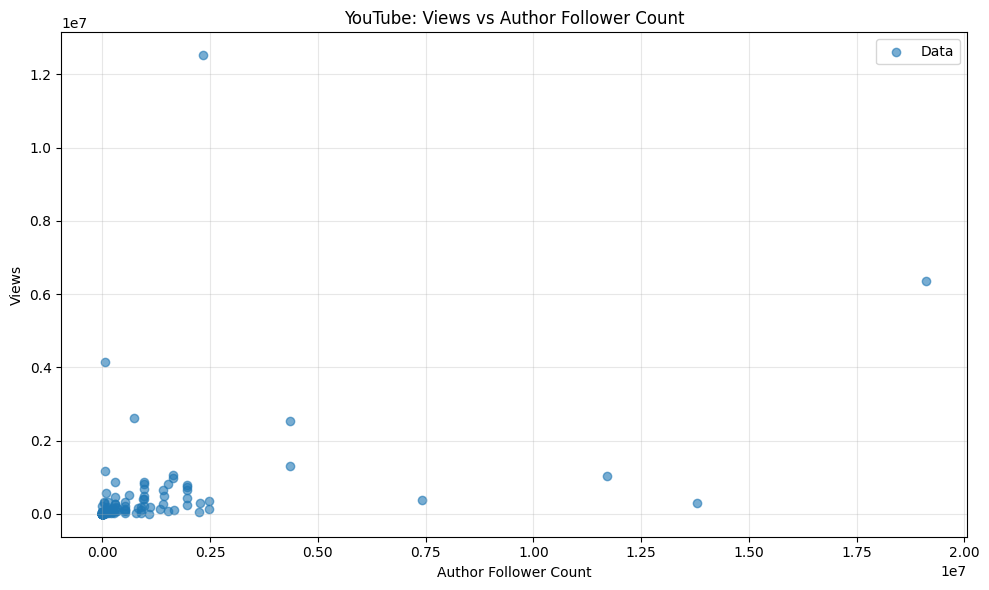

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = df_yt.copy()
plot_df['views'] = pd.to_numeric(plot_df['views'], errors='coerce')
plot_df['author_follower_count'] = pd.to_numeric(plot_df['author_follower_count'], errors='coerce')
plot_df = plot_df.dropna(subset=['views', 'author_follower_count'])

x = plot_df['author_follower_count']
y = plot_df['views']

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Data')

plt.title('YouTube: Views vs Author Follower Count')
plt.xlabel('Author Follower Count')
plt.ylabel('Views')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. TikTok Views vs Follower Count


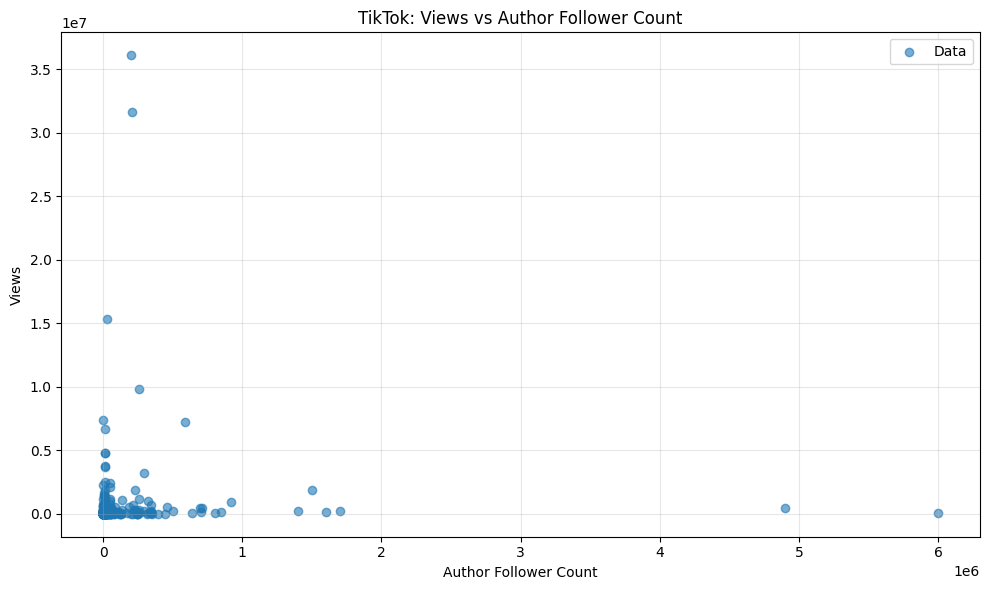

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = df_tiktok.copy()
plot_df['views'] = pd.to_numeric(plot_df['views'], errors='coerce')
plot_df['author_follower_count'] = pd.to_numeric(plot_df['author_follower_count'], errors='coerce')
plot_df = plot_df.dropna(subset=['views', 'author_follower_count'])

x = plot_df['author_follower_count']
y = plot_df['views']

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Data')

plt.title('TikTok: Views vs Author Follower Count')
plt.xlabel('Author Follower Count')
plt.ylabel('Views')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 4. Surprise Hits and Flops

Identify:
- **Surprise hits**: low follower count + huge reach
- **Flops**: big account + low engagement


In [ ]:
import numpy as np

work_df = df.copy()
work_df['views'] = pd.to_numeric(work_df['views'], errors='coerce')
work_df['author_follower_count'] = pd.to_numeric(work_df['author_follower_count'], errors='coerce')

# Vectorized safe divide (avoids inf on zero followers)
work_df['views_per_follower'] = np.divide(
    work_df['views'],
    work_df['author_follower_count'],
    out=np.full(len(work_df), np.nan, dtype='float64'),
    where=work_df['author_follower_count'].gt(0),
)

# Write back column to df, preserving your main dataframe
df['views_per_follower'] = work_df['views_per_follower']

SHOW_COLS = [
    'source',
    'video_id',
    'video_title',
    'channel_title',
    'views',
    'author_follower_count',
    'views_per_follower',
]

def platform_top5(label, source_name):
    p = work_df.loc[work_df['source'].eq(source_name)].dropna(subset=['views_per_follower'])

    print(f'\n{label} - Top 5 LOWEST views_per_follower')
    display(p.nsmallest(5, 'views_per_follower')[SHOW_COLS])

    print(f'\n{label} - Top 5 HIGHEST views_per_follower')
    display(p.nlargest(5, 'views_per_follower')[SHOW_COLS])

platform_top5('TikTok', 'TikTok')
platform_top5('YouTube', 'Youtube')



TikTok - Top 5 LOWEST views_per_follower


,source,video_id,video_title,channel_title,views,author_follower_count,views_per_follower
209,TikTok,7576815774464003359,NaN,NaN,1696,314500,0.005393
205,TikTok,7582341803022601486,NaN,NaN,45300,6000000,0.007550
285,TikTok,7600780863105813791,NaN,NaN,4948,241000,0.020531
138,TikTok,7573597953470876959,NaN,NaN,1149,46500,0.024710
33,TikTok,7599116294566235447,NaN,NaN,13000,441600,0.029438



TikTok - Top 5 HIGHEST views_per_follower


,source,video_id,video_title,channel_title,views,author_follower_count,views_per_follower
4,TikTok,7581702595585068319,NaN,NaN,13400,2,6700.000000
45,TikTok,7583248532102991134,NaN,NaN,497200,88,5650.000000
223,TikTok,7565014030482525471,NaN,NaN,39900,8,4987.500000
214,TikTok,7563717533480586510,NaN,NaN,809300,185,4374.594595
8,TikTok,7564678613115604255,NaN,NaN,298600,71,4205.633803



YouTube - Top 5 LOWEST views_per_follower


,source,video_id,video_title,channel_title,views,author_follower_count,views_per_follower
414,Youtube,Bngr9lb8MPY,&quot;IM THE VICTIM&quot; Why DoorDash Girl Hi...,MrLboyd Reacts,6599,1070000,0.006167
370,Youtube,pgZTLDI3AAA,DoorDash Girl’s Situation Just Got Way Worse,Mediocre Tutorials and Reviews,15779,902000,0.017493
350,Youtube,Tss1BYWFbtI,Did This Doordash Driver Spray Pepper Spray On...,Inside Edition,296574,13800000,0.021491
369,Youtube,pePQ6YdNww4,DoorDash SA Girl Appears in Court,The Dadvocate,13627,534000,0.025519
338,Youtube,7H-oD45q0MM,DoorDash Girl Situation Is Disgusting,Mori,58991,2230000,0.026453



YouTube - Top 5 HIGHEST views_per_follower


,source,video_id,video_title,channel_title,views,author_follower_count,views_per_follower
392,Youtube,pJGMNIsiiRo,Ring Footage of DoorDash Girl SA #shorts #door...,AI Slop Machine,38935,36,1081.527778
391,Youtube,zfbvk0ALtIQ,Door dash delivery driver falling thru a porch...,Ai Randomz,54342,91,597.164835
384,Youtube,E-iDenM-qVs,Hate then this happens #sora #ai #tornado #wea...,TheHotChew,225896,414,545.642512
390,Youtube,psP1uxfO6CQ,Door dash original video shows door almost ful...,Marie Souto,36643,261,140.394636
404,Youtube,cQQk5cAkcwQ,Ring Doorbell Proof DoorDash Girl Lied And Op...,"Documentaries, Politics And Ai",1968,23,85.565217
